In [ ]:
!pip install -q faiss-cpu seaborn scikit-learn
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.4 MB/s eta 0:00:00:00:0100:01
Done


In [2]:
import os, json, random, warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

import faiss
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
print(f'FAISS   : {faiss.__version__}')

PyTorch : 2.9.0+cu126
Device  : cuda
FAISS   : 1.13.2


In [ ]:

DEFECTIVE_DIR = '/kaggle/input/datasets/vidishagar/not-ok-merged/not_ok_merged'   # 102 zoomed defect images
GOOD_FULL_DIR = '/kaggle/input/datasets/vidishagar/pcb-good/PCB Photographs 18th Feb 2026'   #  good PCB images
# ═══════════════════════════════════════════════

WORK_DIR      = '/kaggle/working'

# Patch extraction
PATCH_OVERLAP  = 0.25    # 25% overlap when tiling good PCBs
RANDOM_SEED    = 42

# Feature extraction
IMG_SIZE       = 224     # backbone input size
BATCH_SIZE     = 32

# Memory bank

SUBSAMPLE_RATIO = 1.0

# Threshold strategy: 'percentile' or 'manual'
THRESHOLD_STRATEGY  = 'manual'
THRESHOLD_PERCENTILE = 95    # 95 = flag top 5% most anomalous patches as defects
THRESHOLD_MANUAL    = 0.39   

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print('Config loaded.')

Config loaded.


Defective images  : 207
Good full images  : 28
Patch size (W x H): 1280 x 720 px


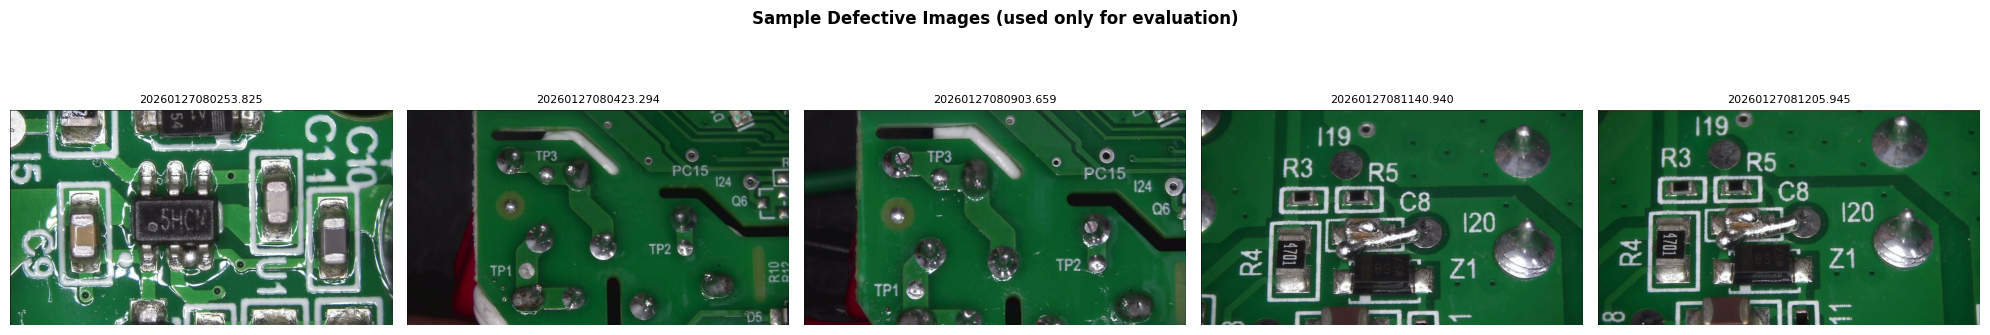

In [49]:
def get_image_paths(folder):
    exts = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG')
    paths = []
    for ext in exts:
        paths.extend(Path(folder).glob(ext))
    return sorted(paths)

defect_imgs   = get_image_paths(DEFECTIVE_DIR)
good_full_imgs = get_image_paths(GOOD_FULL_DIR)

print(f'Defective images  : {len(defect_imgs)}')
print(f'Good full images  : {len(good_full_imgs)}')
assert len(defect_imgs) > 0,    'No defective images found — check DEFECTIVE_DIR'
assert len(good_full_imgs) > 0, 'No good images found — check GOOD_FULL_DIR'

# Detect patch size
from collections import Counter
size_counts = Counter()
for p in defect_imgs:
    img = cv2.imread(str(p))
    if img is not None:
        size_counts[img.shape[:2]] += 1

PATCH_H, PATCH_W = size_counts.most_common(1)[0][0]

if len(size_counts) > 1:
    print(f'WARNING: Mixed defect image sizes: {dict(size_counts)}')
    print(f'Using most common: {PATCH_W}x{PATCH_H}')
else:
    print(f'Patch size (W x H): {PATCH_W} x {PATCH_H} px')

# Preview
n_preview = min(5, len(defect_imgs))
fig, axes = plt.subplots(1, n_preview, figsize=(4*n_preview, 4))
if n_preview == 1: axes = [axes]
for ax, p in zip(axes, defect_imgs[:n_preview]):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(p.name[:18], fontsize=8); ax.axis('off')
plt.suptitle('Sample Defective Images (used only for evaluation)', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
class FeatureExtractor(nn.Module):
    """
    WideResNet-50 with the classification head removed.
    Returns a 2048-dim feature vector per image.
    """
    def __init__(self):
        super().__init__()
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1
        )
        # Keep everything except the final FC layer
        self.features = nn.Sequential(*list(backbone.children())[:-1])

    def forward(self, x):
        return self.features(x).squeeze(-1).squeeze(-1)  # (B, 2048)

extractor = FeatureExtractor().to(DEVICE)
extractor.eval()
for param in extractor.parameters():
    param.requires_grad = False

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = extractor(dummy)
print(f'Backbone output shape: {out.shape}')  # should be (2, 2048)
print('Feature extractor ready — no training needed.')

Backbone output shape: torch.Size([2, 2048])
Feature extractor ready — no training needed.


In [51]:
GOOD_PATCHES_DIR = '/kaggle/input/datasets/vidishagar/ok-merged/OK PHOTOS_MERGED'

def get_patch_paths(folder):
    exts = ('*.jpg','*.jpeg','*.png','*.JPG','*.PNG')
    paths = []
    for ext in exts:
        paths.extend(Path(folder).glob(ext))
    return sorted(paths)

good_patch_paths = get_patch_paths(GOOD_PATCHES_DIR)

print(f'Good patches loaded: {len(good_patch_paths)}')

Good patches loaded: 1061


In [52]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PatchDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), str(self.paths[idx])

good_dataset = PatchDataset(good_patch_paths, transform)
good_loader  = DataLoader(good_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

all_features = []
with torch.no_grad():
    for imgs, _ in tqdm(good_loader, desc='Extracting features from good patches'):
        feats = extractor(imgs.to(DEVICE))
        all_features.append(feats.cpu().numpy())

all_features = np.vstack(all_features).astype(np.float32)
print(f'Feature matrix shape: {all_features.shape}')  # (N_patches, 2048)
print(f'Memory: {all_features.nbytes / 1e6:.1f} MB')

Extracting features from good patches:   0%|          | 0/34 [00:00<?, ?it/s]

Feature matrix shape: (1061, 2048)
Memory: 8.7 MB


In [14]:
len(good_patch_paths)

1061

In [61]:
import numpy as np

# Subsample
n_total = len(all_features)
n_keep  = max(200, int(n_total * SUBSAMPLE_RATIO))
if n_keep < n_total:
    idx            = np.random.choice(n_total, size=n_keep, replace=False)
    memory_bank    = all_features[idx]
    print(f'Subsampled: {n_total} → {n_keep} features ({SUBSAMPLE_RATIO:.0%})')
else:
    memory_bank = all_features
    print(f'Using all {n_total} features (no subsampling)')

# L2-normalize features (makes cosine distance equivalent to L2 on unit sphere)
norms       = np.linalg.norm(memory_bank, axis=1, keepdims=True) + 1e-8
memory_norm = (memory_bank / norms).astype(np.float32)

# Build FAISS flat index (exact L2 search)
dim   = memory_norm.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(memory_norm)

print(f'\nFAISS index built.')
print(f'  Vectors in index : {index.ntotal}')
print(f'  Feature dimension: {dim}')

Using all 1061 features (no subsampling)

FAISS index built.
  Vectors in index : 1061
  Feature dimension: 2048


Threshold (manual): 0.3900


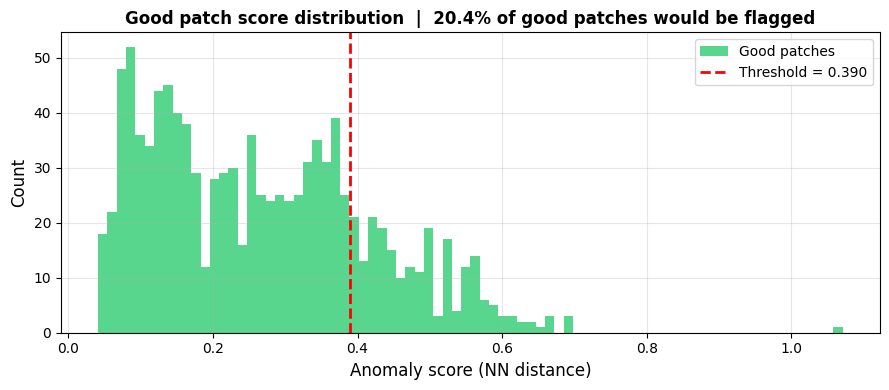


Good patch scores — mean: 0.2655  std: 0.1510  max: 1.0711


In [62]:
# Score all good patches (should have low distance = low anomaly score)
norms_all  = np.linalg.norm(all_features, axis=1, keepdims=True) + 1e-8
feats_norm = (all_features / norms_all).astype(np.float32)

# k=2 because the nearest neighbor of a vector already in the index is itself
D_good, _ = index.search(feats_norm, k=2)
scores_good = np.sqrt(D_good[:, 1])  # skip self-match at k=0

# Set threshold
if THRESHOLD_STRATEGY == 'percentile':
    THRESHOLD = float(np.percentile(scores_good, THRESHOLD_PERCENTILE))
    print(f'Threshold (percentile={THRESHOLD_PERCENTILE}): {THRESHOLD:.4f}')
else:
    assert THRESHOLD_MANUAL is not None, 'Set THRESHOLD_MANUAL in Cell 3'
    THRESHOLD = float(THRESHOLD_MANUAL)
    print(f'Threshold (manual): {THRESHOLD:.4f}')

# Plot good patch score distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_good, bins=80, color='#2ecc71', alpha=0.8, label='Good patches')
ax.axvline(THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'Threshold = {THRESHOLD:.3f}')
pct_flagged = (scores_good > THRESHOLD).mean() * 100
ax.set_xlabel('Anomaly score (NN distance)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Good patch score distribution  |  {pct_flagged:.1f}% of good patches would be flagged',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nGood patch scores — mean: {scores_good.mean():.4f}  std: {scores_good.std():.4f}  max: {scores_good.max():.4f}')

In [44]:
DEFECT_PATCHES_DIR = '/kaggle/input/datasets/vidishagar/not-ok-merged/not_ok_merged'

defect_imgs = get_patch_paths(DEFECT_PATCHES_DIR)

print(f'Defect patches loaded: {len(defect_imgs)}')

Defect patches loaded: 207


Scoring defect patches:   0%|          | 0/207 [00:00<?, ?it/s]

Defect scores — mean: 0.4834  std: 0.1335  min: 0.0000


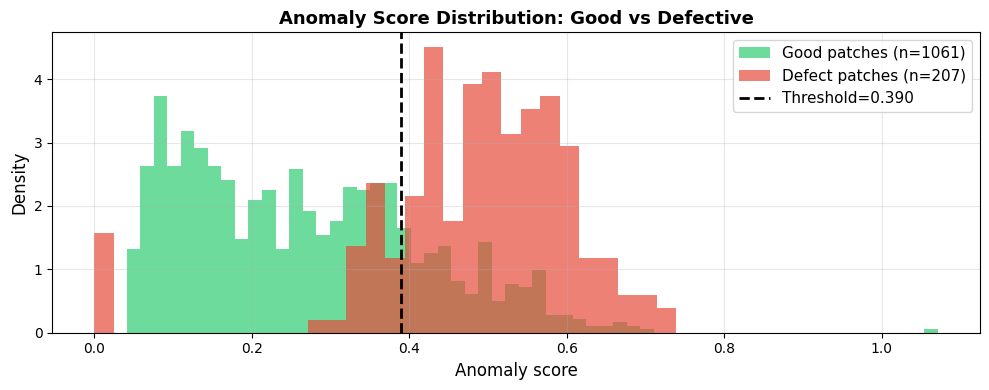


Separation (defect_mean - good_mean): 0.2180
A positive value means defects score higher — good!
If near zero, try a different backbone or check image quality.


In [63]:
@torch.no_grad()
def score_image_patch(bgr_patch):
    """Return anomaly score for a single BGR numpy patch."""
    rgb  = cv2.cvtColor(bgr_patch, cv2.COLOR_BGR2RGB)
    pil  = Image.fromarray(rgb)
    t    = transform(pil).unsqueeze(0).to(DEVICE)
    feat = extractor(t).cpu().numpy().astype(np.float32)        # (1, 2048)
    feat = feat / (np.linalg.norm(feat, axis=1, keepdims=True) + 1e-8)
    D, _ = index.search(feat, k=1)
    return float(np.sqrt(D[0, 0]))

scores_defect = []
for p in tqdm(defect_imgs, desc='Scoring defect patches'):
    img = cv2.imread(str(p))
    if img is not None:
        scores_defect.append(score_image_patch(img))

scores_defect = np.array(scores_defect)
print(f'Defect scores — mean: {scores_defect.mean():.4f}  std: {scores_defect.std():.4f}  min: {scores_defect.min():.4f}')

# Compare distributions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_good,   bins=60, color='#2ecc71', alpha=0.7, label=f'Good patches (n={len(scores_good)})', density=True)
ax.hist(scores_defect, bins=30, color='#e74c3c', alpha=0.7, label=f'Defect patches (n={len(scores_defect)})', density=True)
ax.axvline(THRESHOLD, color='black', linewidth=2, linestyle='--', label=f'Threshold={THRESHOLD:.3f}')
ax.set_xlabel('Anomaly score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Anomaly Score Distribution: Good vs Defective', fontweight='bold', fontsize=13)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# If the distributions overlap heavily, lower the percentile threshold
sep = scores_defect.mean() - scores_good.mean()
print(f'\nSeparation (defect_mean - good_mean): {sep:.4f}')
print('A positive value means defects score higher — good!')
print('If near zero, try a different backbone or check image quality.')

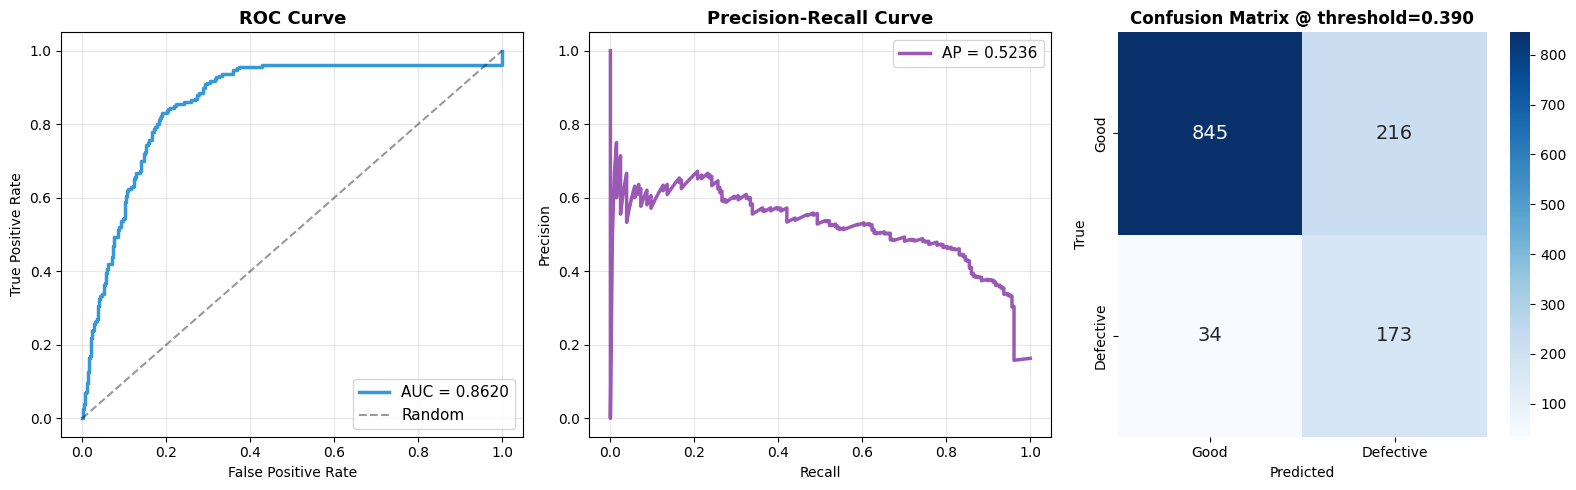

AUC-ROC          : 0.8620
Average Precision: 0.5236

Classification report at threshold=0.390:
              precision    recall  f1-score   support

        Good       0.96      0.80      0.87      1061
   Defective       0.44      0.84      0.58       207

    accuracy                           0.80      1268
   macro avg       0.70      0.82      0.73      1268
weighted avg       0.88      0.80      0.82      1268



In [64]:
# Sample an equal-ish number of good scores for evaluation
# (don't need all thousands, just a representative set)
n_eval_good = min(len(scores_defect) * 10, len(scores_good))
eval_good   = np.random.choice(scores_good, size=n_eval_good, replace=False)

all_scores = np.concatenate([eval_good, scores_defect])
all_labels = np.array([0]*len(eval_good) + [1]*len(scores_defect))

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_scores)
auc_score = roc_auc_score(all_labels, all_scores)

# Precision-Recall
prec, rec, _ = precision_recall_curve(all_labels, all_scores)
ap = average_precision_score(all_labels, all_scores)

# Confusion matrix at chosen threshold
preds_at_threshold = (all_scores >= THRESHOLD).astype(int)
cm = confusion_matrix(all_labels, preds_at_threshold)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'AUC = {auc_score:.4f}')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold', fontsize=13)
ax.legend(fontsize=11); ax.grid(alpha=0.3)

# Precision-Recall
ax = axes[1]
ax.plot(rec, prec, color='#9b59b6', linewidth=2.5, label=f'AP = {ap:.4f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
ax.legend(fontsize=11); ax.grid(alpha=0.3)

# Confusion matrix
ax = axes[2]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Good','Defective'], yticklabels=['Good','Defective'],
            annot_kws={'size':14})
ax.set_title(f'Confusion Matrix @ threshold={THRESHOLD:.3f}', fontweight='bold', fontsize=12)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout(); plt.show()

print(f'AUC-ROC          : {auc_score:.4f}')
print(f'Average Precision: {ap:.4f}')
print(f'\nClassification report at threshold={THRESHOLD:.3f}:')
print(classification_report(all_labels, preds_at_threshold,
                            target_names=['Good','Defective']))

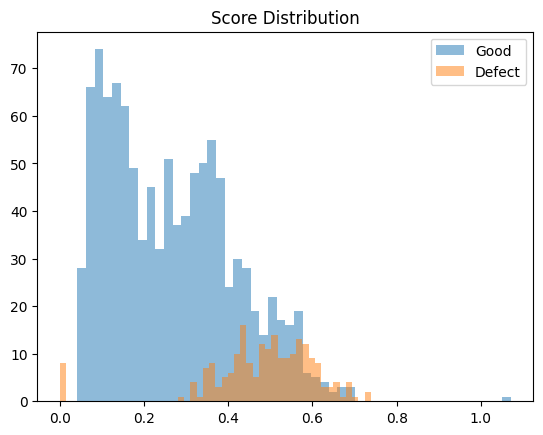

In [58]:
import matplotlib.pyplot as plt

plt.hist(scores_good, bins=50, alpha=0.5, label='Good')
plt.hist(scores_defect, bins=50, alpha=0.5, label='Defect')
plt.legend()
plt.title("Score Distribution")
plt.show()

In [59]:
# Try different percentiles and see the trade-off
percentiles_to_try = [80, 85, 90, 95, 99]

print(f'{"Percentile":>12} {"Threshold":>12} {"Good FPR":>10} {"Defect TPR":>12} {"F1":>8}')
print('-' * 60)

from sklearn.metrics import f1_score as sk_f1
results = []
for pct in percentiles_to_try:
    t   = float(np.percentile(scores_good, pct))
    fpr_ = (scores_good   > t).mean()
    tpr_ = (scores_defect > t).mean()
    pred_  = (all_scores >= t).astype(int)
    f1_   = sk_f1(all_labels, pred_, pos_label=1, zero_division=0)
    results.append((pct, t, fpr_, tpr_, f1_))
    print(f'{pct:>12} {t:>12.4f} {fpr_:>10.2%} {tpr_:>12.2%} {f1_:>8.4f}')

print('\nRecommendation:')
best = max(results, key=lambda r: r[4])
print(f'  Best F1 at percentile={best[0]}, threshold={best[1]:.4f}')
print(f'  → Update THRESHOLD_PERCENTILE in Cell 3 and re-run Cell 9+')

  Percentile    Threshold   Good FPR   Defect TPR       F1
------------------------------------------------------------
          80       0.3915     19.89%       83.09%   0.5811
          85       0.4313     14.99%       72.46%   0.5792
          90       0.4866      9.99%       54.59%   0.5293
          95       0.5439      4.90%       33.82%   0.4230
          99       0.6254      1.04%        8.70%   0.1525

Recommendation:
  Best F1 at percentile=80, threshold=0.3915
  → Update THRESHOLD_PERCENTILE in Cell 3 and re-run Cell 9+


In [22]:
import pickle

bank = {
    'memory_bank': memory_norm,   # normalized feature vectors
    'threshold':   THRESHOLD,
    'patch_w':     PATCH_W,
    'patch_h':     PATCH_H,
    'img_size':    IMG_SIZE,
    'n_good_patches': len(good_patch_paths),
}

bank_path = f'{WORK_DIR}/pcb_anomaly_memory_bank.pkl'
with open(bank_path, 'wb') as f:
    pickle.dump(bank, f)

size_mb = Path(bank_path).stat().st_size / 1e6
print(f'Memory bank saved: {bank_path}  ({size_mb:.1f} MB)')
print(f'  Vectors   : {memory_norm.shape[0]}')
print(f'  Threshold : {THRESHOLD:.4f}')
print(f'  Patch size: {PATCH_W}x{PATCH_H}')
print('\nDownload this .pkl file from the Output panel to reuse without re-running.')
print('Load it with: bank = pickle.load(open("pcb_anomaly_memory_bank.pkl","rb"))')

NameError: name 'PATCH_W' is not defined